## Univariate analyse — numerieke variabelen

In deze stap onderzoek je de **verdeling van één variabele tegelijk** in je Minecraft-speedrun dataset (`mce.csv`).  
We focussen ons op een paar numerieke kolommen:

- `speedrun_time` — de tijd van de speedrun (in seconden).
- `place` — de positie die de speler behaalde.
- `platform_released_year` — releasejaar van het platform (indien ingevuld).

Doel:  
Inzicht krijgen in vorm en spreiding van deze variabelen:
- Is de verdeling ongeveer normaal (klokvorm)?
- Is de verdeling scheef (links/rechts)?
- Zijn er meerdere pieken (bimodaal / multimodaal)?
- Zijn er uitschieters?

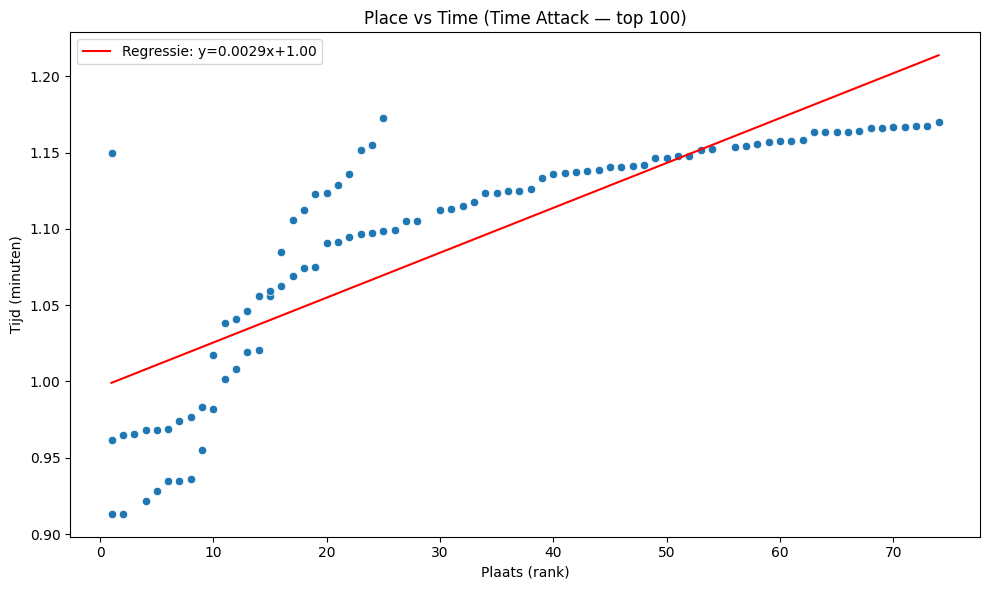

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Laad de dataset
data = pd.read_csv('mce.csv')

# Zorg dat we de juiste categoriekolom gebruiken (soms 'category', soms 'cat_name')
cat_col = 'cat_name' if 'cat_name' in data.columns else ('category' if 'category' in data.columns else None)
if cat_col is None:
    raise KeyError('Geen kolom "cat_name" of "category" gevonden in dataset')

# Maak time_min aan als die ontbreekt maar speedrun_time aanwezig is
if 'time_min' not in data.columns:
    if 'speedrun_time' in data.columns:
        data['time_min'] = data['speedrun_time'] / 60
    else:
        raise KeyError('Geen kolom "time_min" of "speedrun_time" gevonden in dataset')

# Filter voor 'Time Attack' runs en selecteer top 100 op basis van time_min
time_attack_data = data[data[cat_col] == 'Time Attack'].copy()
if time_attack_data.empty:
    raise ValueError('Geen rijen gevonden voor categorie Time Attack')
top100 = time_attack_data.nsmallest(100, 'time_min') if 'time_min' in time_attack_data.columns else time_attack_data

# x en y als numerieke arrays
x = top100['place'].astype(float).values
y = top100['time_min'].astype(float).values

# Bereken de lineaire regressie (voorkom fouten als minder dan 2 punten)
if len(x) < 2:
    raise ValueError('Niet genoeg punten om regressie te berekenen')
coef = np.polyfit(x, y, 1)

# Maak de plot (regressielijn geplot over gelijkmatig verdeelde x voor nette lijn)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=x, y=y, ax=ax)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = coef[0] * x_line + coef[1]
ax.plot(x_line, y_line, color='red', linewidth=1.5, label=f'Regressie: y={coef[0]:.4f}x+{coef[1]:.2f}')
ax.set_xlabel('Plaats (rank)')
ax.set_ylabel('Tijd (minuten)')
ax.set_title('Place vs Time (Time Attack — top 100)')
ax.legend()
plt.tight_layout()
plt.show()

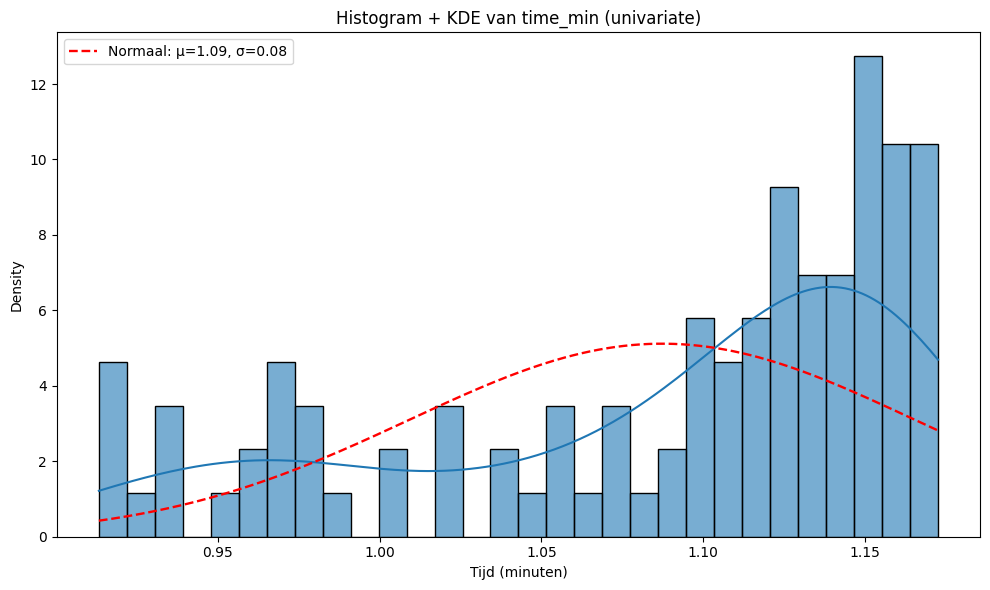

In [ ]:
# Univariate: histogram + KDE + normaalverdeling overlay (time_min)
# We gebruiken 'top100' indien beschikbaar, anders de volledige dataset
series_source = None
if 'top100' in globals():
    df_for_dist = top100
else:
    df_for_dist = data

# Kies de variabele: prefer 'time_min', anders 'speedrun_time' (omzetten naar minuten)
if 'time_min' in df_for_dist.columns:
    series = df_for_dist['time_min'].dropna()
elif 'speedrun_time' in df_for_dist.columns:
    series = (df_for_dist['speedrun_time'] / 60).dropna()
else:
    raise KeyError('Geen kolom  of gevonden voor univariate plot')

import numpy as _np
import seaborn as _sns
import matplotlib.pyplot as _plt

fig, ax = _plt.subplots(figsize=(10, 6))
# Histogram met KDE (density zodat een normaal curve direct vergelijkbaar is)
_sns.histplot(series, kde=True, stat='density', bins=30, color='C0', edgecolor='k', ax=ax, alpha=0.6)

# Normale verdeling overlay (zelfde schaal: density)
mu = series.mean()
sigma = series.std()
x_vals = _np.linspace(series.min(), series.max(), 300)
pdf = (1 / (sigma * _np.sqrt(2 * _np.pi))) * _np.exp(-0.5 * ((x_vals - mu) / sigma) ** 2)
ax.plot(x_vals, pdf, color='red', linestyle='--', linewidth=1.7, label=f'Normaal: μ={mu:.2f}, σ={sigma:.2f}')

ax.set_xlabel('Tijd (minuten)')
ax.set_ylabel('Density')
ax.set_title('Histogram + KDE van time_min (univariate)')
ax.legend()
_plt.tight_layout()
_plt.show()

**Toelichting — Histogram en KDE**

- **Doel:** Visualiseer de verdeling van één numerieke variabele (hier: `time_min`) om te beoordelen of de data normaal verdeeld is, scheef (links/rechts) of multimodaal.
- **Wat te letten:**
  - Normale verdeling: symmetrische klokvorm rondom het gemiddelde.
  - Linksscheef: lange staart naar links (lagere waarden); rechtsscheef: lange staart naar rechts (hogere waarden).
  - Bimodaal / multimodaal: meerdere pieken → mogelijk meerdere subpopulaties (bv. twee typen spelers).
- **Interpretatie:** Als je meerdere pieken ziet kan dat wijzen op heterogene groepen; overweeg segmentatie (per categorie) of aparte analyses per groep.
- **Aanvullende checks:** Gebruik een QQ-plot en statistische tests (Shapiro–Wilk, Kolmogorov–Smirnov) om normaliteit formeel te toetsen; bekijk ook spreiding per `cat_name` of `platform_name`.
- **Volgende stappen:** Maak vergelijkende plots per categorie of pas transformaties toe (bijv. log) bij sterke scheefheid; inspecteer uitschieters en meetinstrumentatiefouten.